# Delhi Daily Climate — Temperature Prediction

Predicts daily mean temperature (`meantemp`) in Delhi using calendar-based seasonality features and same-day weather readings (humidity, wind speed, pressure).

- **Train:** `DailyDelhiClimateTrain.csv` — 2013-01-01 to 2017-01-01 (1,462 days)
- **Test:** `DailyDelhiClimateTest.csv` — 2017-01-01 to 2017-04-24 (114 days), used purely for validation

Source data: [Daily Delhi Climate Data on Kaggle](https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

## 1. Load data

In [2]:
train = pd.read_csv("DailyDelhiClimateTrain.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)
test = pd.read_csv("DailyDelhiClimateTest.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)

print(f"Train: {train['date'].min().date()} to {train['date'].max().date()}  ({len(train)} rows)")
print(f"Test:  {test['date'].min().date()} to {test['date'].max().date()}  ({len(test)} rows)")
train.head()

Train: 2013-01-01 to 2017-01-01  (1462 rows)
Test:  2017-01-01 to 2017-04-24  (114 rows)


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


## 2. Data quality check

`meanpressure` contains clearly invalid readings (raw range runs from about -3 hPa to 7,679 hPa;
realistic sea-level pressure is roughly 950-1050 hPa). Rather than drop rows and break the time series, we clip the column to a realistic range.

In [3]:
print(train['meanpressure'].describe())

for df in (train, test):
    df["meanpressure"] = df["meanpressure"].clip(950, 1050)

count    1462.000000
mean     1011.104548
std       180.231668
min        -3.041667
25%      1001.580357
50%      1008.563492
75%      1014.944901
max      7679.333333
Name: meanpressure, dtype: float64


## 3. Feature engineering

- Cyclical (sin/cos) encoding of day-of-year and month so the model sees Dec 31 → Jan 1 as adjacent, not a hard jump
- Year, to capture any warming/cooling trend across years
- Same-day humidity, wind speed, and (cleaned) pressure as exogenous predictors

In [4]:
def add_features(df):
    df = df.copy()
    doy = df["date"].dt.dayofyear
    df["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    df["month"] = df["date"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["year"] = df["date"].dt.year
    return df

train_fe = add_features(train)
test_fe = add_features(test)

FEATURES = ["doy_sin", "doy_cos", "month_sin", "month_cos", "year",
            "humidity", "wind_speed", "meanpressure"]
TARGET = "meantemp"

X_train, y_train = train_fe[FEATURES], train_fe[TARGET]
X_test, y_test = test_fe[FEATURES], test_fe[TARGET]

## 4. Train and compare models

In [5]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42),
}

results = {}
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds),
    }

results_df = pd.DataFrame(results).T.sort_values("RMSE")
results_df.round(3)

,MAE,RMSE,R2
Linear Regression,2.108,2.555,0.837
Gradient Boosting,2.125,2.740,0.813
Random Forest,2.185,2.800,0.805


In [6]:
best_name = results_df.index[0]
best_preds = predictions[best_name]
print(f"Best model: {best_name}")

Best model: Linear Regression


## 5. Validation: predicted vs actual on test set

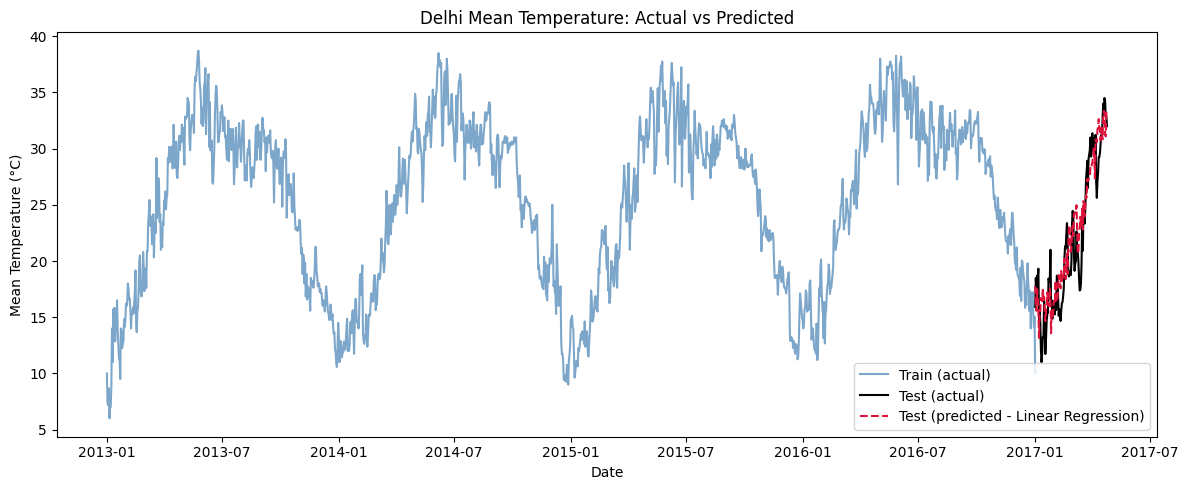

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(train["date"], train["meantemp"], label="Train (actual)", color="steelblue", alpha=0.7)
plt.plot(test["date"], test["meantemp"], label="Test (actual)", color="black")
plt.plot(test["date"], best_preds, label=f"Test (predicted - {best_name})", color="crimson", linestyle="--")
plt.title("Delhi Mean Temperature: Actual vs Predicted")
plt.xlabel("Date"); plt.ylabel("Mean Temperature (°C)"); plt.legend(); plt.tight_layout()
plt.show()

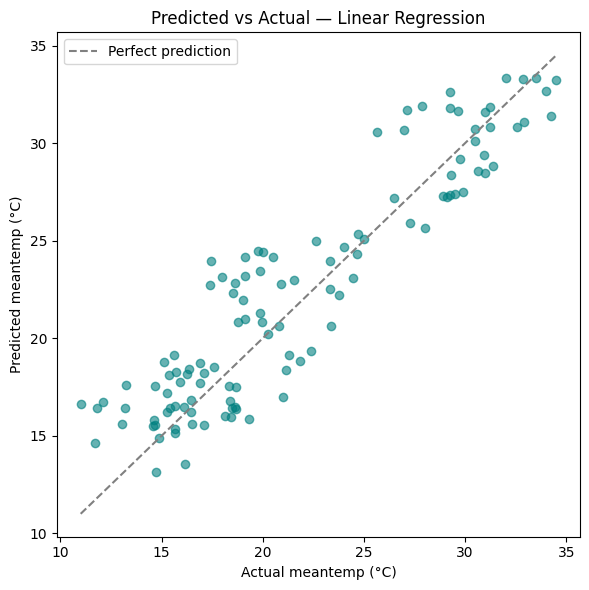

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_preds, alpha=0.6, color="teal")
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, color="gray", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual meantemp (°C)"); plt.ylabel("Predicted meantemp (°C)")
plt.title(f"Predicted vs Actual — {best_name}"); plt.legend(); plt.tight_layout()
plt.show()

## 6. Findings

- All three models explain 80%+ of the variance in test-set temperature (R² > 0.80), with **Linear Regression** slightly ahead — the seasonal signal is strongly periodic, so a linear model on cyclical date features captures most of it.
- Mean absolute error is about **2.1°C**, meaning day-to-day predictions are typically within ~2 degrees of actual.
- Tree-based models (Random Forest, Gradient Boosting) don't outperform here — the relationship between calendar position and temperature is smooth and mostly linear once cyclically encoded, so extra model complexity isn't buying much.
- Next steps to improve accuracy: add lagged temperature (yesterday's temp), rolling averages, or an explicit time-series model (SARIMA/Prophet) to capture short-term momentum, not just seasonal position.